Install/import packages

In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares, minimize_scalar
import matplotlib.pyplot as plt

Upload and load the data

In [13]:
from google.colab import files
uploaded = files.upload()  # choose xy_data.csv when prompted

df = pd.read_csv('xy_data.csv')
X_data = df['x'].values
Y_data = df['y'].values
N = len(X_data)
print(df.shape)
df.head()

Saving xy_data.csv to xy_data (1).csv
(1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


Look at the raw data first

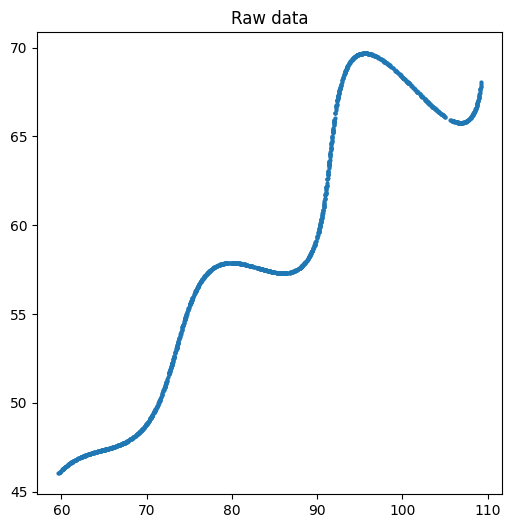

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(X_data, Y_data, s=4)
plt.title("Raw data")
plt.show()

Define the parametric model

In [15]:
def curve_xy(t, theta, M, X):
    e = np.exp(M * np.abs(t))
    s03 = np.sin(0.3 * t)
    x = t*np.cos(theta) - e*s03*np.sin(theta) + X
    y = 42 + t*np.sin(theta) + e*s03*np.cos(theta)
    return x, y


Function to assign the best-fit t to each data point

In [16]:
def assign_t(theta, M, X, t_grid):
    cx, cy = curve_xy(t_grid, theta, M, X)
    t_best = np.empty(N)
    for i in range(N):
        d2 = (cx - X_data[i])**2 + (cy - Y_data[i])**2
        t_best[i] = t_grid[np.argmin(d2)]

    # refine each match with a local 1D search
    refined = np.empty(N)
    for i in range(N):
        t0 = t_best[i]
        lo, hi = max(6, t0-1), min(60, t0+1)
        def obj(t):
            cx1, cy1 = curve_xy(np.array([t]), theta, M, X)
            return (cx1[0]-X_data[i])**2 + (cy1[0]-Y_data[i])**2
        refined[i] = minimize_scalar(obj, bounds=(lo, hi), method='bounded').x
    return refined

Function to refit theta, M, X given the t assignments

In [17]:
def residuals_given_t(params, t_arr):
    theta, M, X = params
    x, y = curve_xy(t_arr, theta, M, X)
    return np.concatenate([x - X_data, y - Y_data])

Run the iterative fit (alternating optimization)

In [18]:
theta, M, X = np.deg2rad(25), 0.0, 50.0   # initial guess
t_grid = np.linspace(6, 60, 3000)

for it in range(40):
    t_assigned = assign_t(theta, M, X, t_grid)
    result = least_squares(
        residuals_given_t, [theta, M, X], args=(t_assigned,),
        bounds=([0, -0.05, 0], [np.deg2rad(50), 0.05, 100])
    )
    theta, M, X = result.x
    if it % 5 == 0:
        print(it, np.rad2deg(theta), M, X, np.sum(result.fun**2))

print("\nFINAL RESULT")
print("theta (deg) =", np.rad2deg(theta))
print("M =", M)
print("X =", X)
print("max residual =", np.max(np.abs(result.fun)))

0 26.95277629179323 0.016218654695271253 50.73791427685535 7314.527007814373
5 29.28486147055355 0.029088713356015705 53.89935318053339 513.5519272288318
10 29.843458810478552 0.029851077988599074 54.75285740878747 25.759386696783885
15 29.96518029751741 0.02996835174798964 54.94457875893788 1.2930471361157596
20 29.99217355423983 0.029993008678402072 54.98755718164195 0.06507515376266204
25 29.99821873887967 0.02999844132238377 54.997201415578296 0.003287784175857806
30 29.99957874403175 0.02999964842656589 54.99936942143869 0.00016625361146832985
35 29.99988442020601 0.02999991969940976 54.99985679644575 8.433658456213435e-06

FINAL RESULT
theta (deg) = 29.999946205415615
M = 0.029999974466888974
X = 54.999955297538264
max residual = 4.1482580314777806e-05


Verify visually

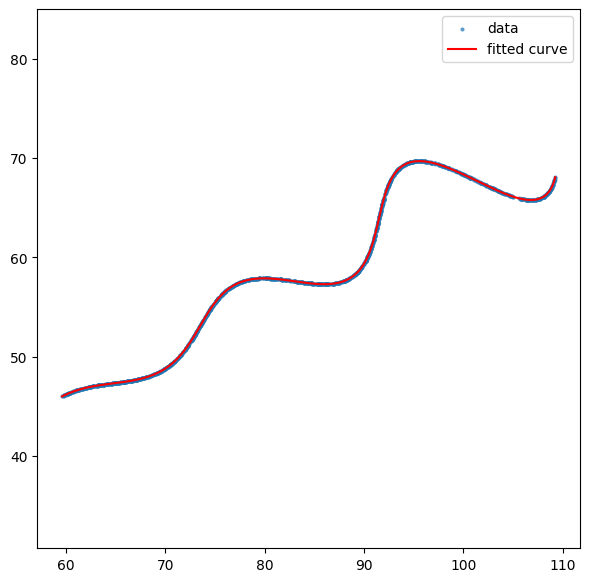

In [19]:
t = np.linspace(6, 60, 2000)
xc, yc = curve_xy(t, theta, M, X)

plt.figure(figsize=(7,7))
plt.scatter(X_data, Y_data, s=4, alpha=0.6, label='data')
plt.plot(xc, yc, 'r', lw=1.5, label='fitted curve')
plt.legend()
plt.axis('equal')
plt.show()

Final answer (Desmos/LaTeX format for submission)

In [20]:
theta_deg = np.rad2deg(theta)
print(f"theta = {theta_deg:.4f} deg -> rounds to 30 deg")
print(f"M     = {M:.6f} -> rounds to 0.03")
print(f"X     = {X:.6f} -> rounds to 55")

latex = (
    f"\\left(t*\\cos({theta:.10f})-e^{{{M:.4f}\\left|t\\right|}}\\cdot"
    f"\\sin(0.3t)\\sin({theta:.10f})+{X:.4f},"
    f"42+t*\\sin({theta:.10f})+e^{{{M:.4f}\\left|t\\right|}}\\cdot"
    f"\\sin(0.3t)\\cos({theta:.10f})\\right)"
)
print(latex)

theta = 29.9999 deg -> rounds to 30 deg
M     = 0.030000 -> rounds to 0.03
X     = 54.999955 -> rounds to 55
\left(t*\cos(0.5235978367)-e^{0.0300\left|t\right|}\cdot\sin(0.3t)\sin(0.5235978367)+55.0000,42+t*\sin(0.5235978367)+e^{0.0300\left|t\right|}\cdot\sin(0.3t)\cos(0.5235978367)\right)


In [21]:
# --- Self L1 check: does rounding to clean values hurt accuracy? ---
theta_clean, M_clean, X_clean = np.deg2rad(30), 0.03, 55

t_uniform = np.linspace(6, 60, 1000)
x_fit, y_fit = curve_xy(t_uniform, theta, M, X)              # raw fitted params
x_clean, y_clean = curve_xy(t_uniform, theta_clean, M_clean, X_clean)  # rounded params

l1 = np.mean(np.abs(x_fit - x_clean) + np.abs(y_fit - y_clean))
print(f"L1 distance (fitted vs. rounded clean values): {l1:.6e}")

L1 distance (fitted vs. rounded clean values): 5.626027e-05
